🚀 EJECUTANDO TEST DE RENDIMIENTO...
   🧪 Probando: GPT-4o Mini...


100%|██████████| 5/5 [00:11<00:00,  2.26s/it]


   🧪 Probando: Llama 3 8B...


100%|██████████| 5/5 [00:10<00:00,  2.20s/it]


   🧪 Probando: Claude 3.5 Sonnet...


100%|██████████| 5/5 [00:06<00:00,  1.33s/it]


   🧪 Probando: Mistral Large...


100%|██████████| 5/5 [00:27<00:00,  5.56s/it]
/tmp/ipython-input-4141933715.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=df, x="Modelo", y="Latencia Media (s)", palette="viridis")
/tmp/ipython-input-4141933715.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=df, x="Modelo", y="Coste Proyectado (10k reqs)", palette="magma")


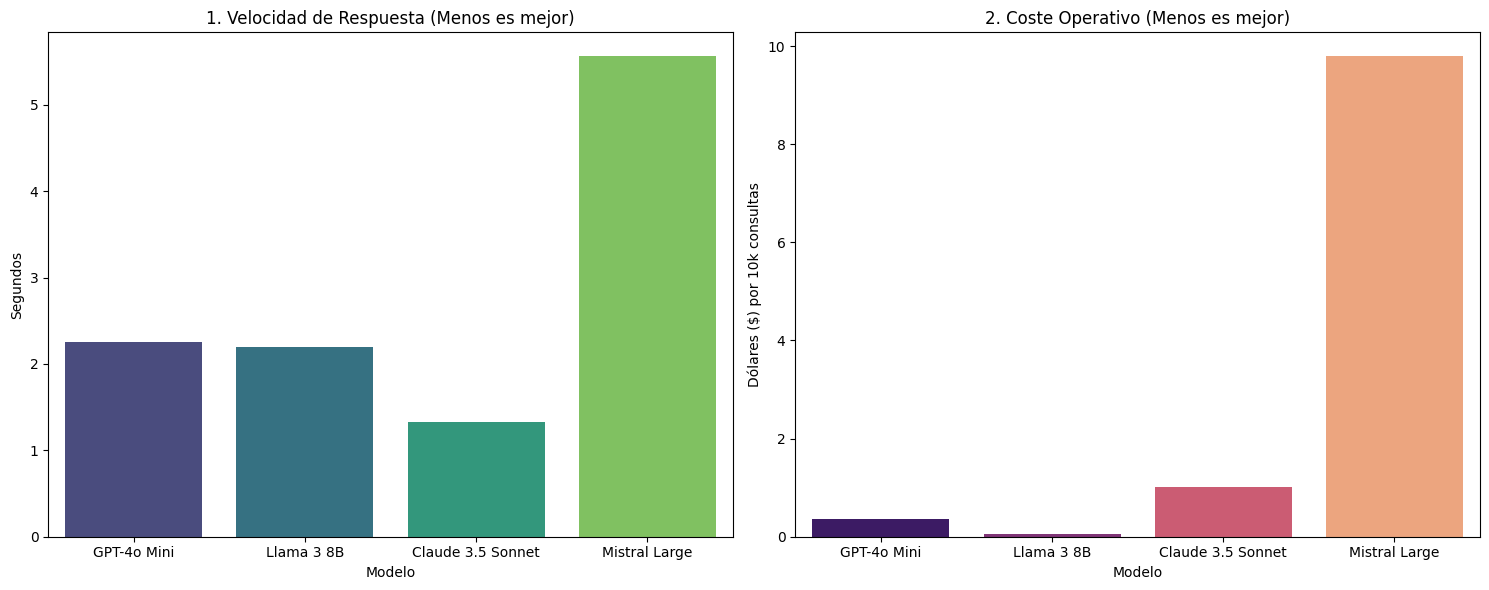

In [ ]:
# ==========================================
# 📊 BENCHMARK GPT-4o Mini: VELOCIDAD Y COSTE
# ==========================================
!pip install openai pandas matplotlib seaborn tqdm

import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from openai import OpenAI
from tqdm import tqdm

# --- CONFIGURACIÓN ---
# Tu clave OpenRouter
OPENROUTER_KEY = "api_openrouter"

# Modelos a Comparar
MODELS = {
    "GPT-4o Mini": {
        "id": "openai/gpt-4o-mini",
        "cost_in": 0.15, "cost_out": 0.60  # $ por 1M tokens
    },
    "Llama 3.3 70B": {
        "id": "meta-llama/llama-3.3-70b-instruct",
        "cost_in": 0.7, "cost_out": 0.9 # Aprox en OpenRouter
    },
    "Claude 3.5 Sonnet": {
        "id": "anthropic/claude-3.5-sonnet",
        "cost_in": 3.00, "cost_out": 15.00
    },
    "Mistral Large": {
        "id": "mistralai/mistral-large",
        "cost_in": 2.00, "cost_out": 6.00
    }
}

client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=OPENROUTER_KEY)

# Preguntas de prueba (Simulamos uso real)
prompts = [
    "Dime el director de Titanic",
    "Busca en el guion de Matrix la frase de la pastilla roja",
    "Peliculas de terror de 1999",
    "Busca una pelicula sobre un barco que se hunde",
    "Actores de Pulp Fiction"
]

results = []

print("🚀 EJECUTANDO TEST DE RENDIMIENTO...")

for name, conf in MODELS.items():
    print(f"   🧪 Probando: {name}...")
    latencias = []
    tokens_input_acum = 0
    tokens_output_acum = 0

    # Hacemos 5 peticiones por modelo para sacar media
    for p in tqdm(prompts):
        start = time.time()
        try:
            resp = client.chat.completions.create(
                model=conf["id"],
                messages=[
                    {"role": "system", "content": "Eres un asistente. Responde JSON: {'tool': 'name'}"},
                    {"role": "user", "content": p}
                ]
            )
            lat = time.time() - start
            latencias.append(lat)

            # Estimación de tokens (1 palabra ~= 1.3 tokens)
            out_text = resp.choices[0].message.content
            tokens_input_acum += len(p.split()) * 1.3
            tokens_output_acum += len(out_text.split()) * 1.3

        except:
            latencias.append(0) # Error

    avg_lat = sum(latencias) / len(latencias)

    # Calcular coste proyectado para 10.000 peticiones iguales
    coste_in = (tokens_input_acum * 2000) / 1_000_000 * conf['cost_in']
    coste_out = (tokens_output_acum * 2000) / 1_000_000 * conf['cost_out']
    total_cost_project = coste_in + coste_out

    results.append({
        "Modelo": name,
        "Latencia Media (s)": avg_lat,
        "Coste Proyectado (10k reqs)": total_cost_project
    })

# --- GRAFICAR ---
df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Latencia
sns.barplot(ax=axes[0], data=df, x="Modelo", y="Latencia Media (s)", palette="viridis")
axes[0].set_title("1. Velocidad de Respuesta (Menos es mejor)")
axes[0].set_ylabel("Segundos")

# Gráfico 2: Coste
sns.barplot(ax=axes[1], data=df, x="Modelo", y="Coste Proyectado (10k reqs)", palette="magma")
axes[1].set_title("2. Coste Operativo (Menos es mejor)")
axes[1].set_ylabel("Dólares ($) por 10k consultas")

plt.tight_layout()
plt.show()

📂 Cargando sinopsis del CSV...
✅ Generadas 50 preguntas basadas en tus datos reales.
   Ejemplo Semántico: Busca una película que trate de: Junko nació con una enfermedad mental: pirokinesis. Quema todo lo que se le pone al alcance, incluso personas. Junko está enamorada de Kazuki, un jove...

🚀 EJECUTANDO TEST DE COMPRENSIÓN SEMÁNTICA...


Mistral 7B: 100%|██████████| 50/50 [00:51<00:00,  1.04s/it]
/tmp/ipython-input-2814474672.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df_res['Modelo'], y=df_res['Precisión Semántica (%)'], palette=colors)


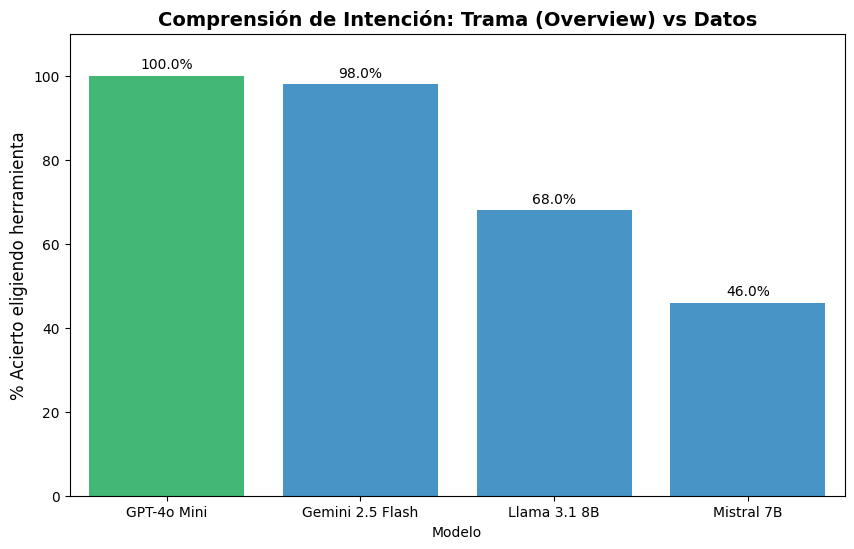

             Modelo  Precisión Semántica (%)  Confusión Trama/Guion
0       GPT-4o Mini                    100.0                      0
1  Gemini 2.5 Flash                     98.0                      0
2      Llama 3.1 8B                     68.0                      1
3        Mistral 7B                     46.0                      0


In [ ]:
# ==========================================
# 🧠 BENCHMARK SEMÁNTICO (OVERVIEWS REALES)
# ==========================================
!pip install openai pandas matplotlib seaborn tqdm

import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time
from openai import OpenAI
from tqdm import tqdm

# --- 1. CONFIGURACIÓN ---
OPENROUTER_KEY = "api_openrouter"
CSV_PATH = "peliculas_completas.csv"

# Modelos Ligeros para Comparar
MODELS = {
    "GPT-4o Mini": "openai/gpt-4o-mini",
    "Gemini 2.5 Flash": "google/gemini-2.5-flash",
    "Llama 3.1 8B": "meta-llama/llama-3.1-8b-instruct",
    "Mistral 7B": "mistralai/mistral-7b-instruct"
}

client = OpenAI(base_url="https://openrouter.ai/api/v1", api_key=OPENROUTER_KEY)

# --- 2. GENERAR DATASET DESDE EL CSV ---
print("📂 Cargando sinopsis del CSV...")
try:
    df = pd.read_csv(CSV_PATH)
    # Filtramos pelis que tengan sinopsis
    df = df.dropna(subset=['overview', 'title'])

    # Seleccionamos 40 películas al azar
    sample = df.sample(40)

    test_cases = []
    for _, row in sample.iterrows():
        # Simulamos un usuario contando la trama
        # Cogemos los primeros 150 caracteres de la sinopsis para que no sea tan obvio
        trama_parcial = row['overview'][:150] + "..."

        test_cases.append({
            "q": f"Busca una película que trate de: {trama_parcial}",
            "expect": "elastic_semantic_search",
            "title": row['title'] # Solo para referencia
        })

    # Añadimos 10 casos de control (Datos exactos) para ver si distingue
    control_sample = df.sample(10)
    for _, row in control_sample.iterrows():
        test_cases.append({
            "q": f"¿Quién es el director de {row['title']}?",
            "expect": "api_search_movie",
            "title": row['title']
        })

    print(f"✅ Generadas {len(test_cases)} preguntas basadas en tus datos reales.")
    print(f"   Ejemplo Semántico: {test_cases[0]['q']}")

except Exception as e:
    print(f"❌ Error leyendo CSV: {e}")
    test_cases = []

# --- 3. SYSTEM PROMPT ---
SYSTEM_PROMPT = """Eres CineBot. Clasifica la intención del usuario y devuelve JSON.

HERRAMIENTAS:
1. `elastic_semantic_search(concepto)`: Úsala cuando el usuario describa una TRAMA, SINOPSIS o TEMÁTICA ("peli sobre guerras", "historia de amor").
2. `search_script(frase)`: Úsala SOLO para buscar diálogos literales o citas.
3. `api_search_movie(titulo)`: Úsala para buscar datos técnicos dado un TÍTULO.

FORMATO: {"tool": "nombre", "parameters": {"param": "val"}}
"""

# --- 4. EJECUCIÓN ---
results = []
print("\n🚀 EJECUTANDO TEST DE COMPRENSIÓN SEMÁNTICA...")

for model_name, model_id in MODELS.items():
    aciertos = 0
    errores_confusion = 0 # Confundir trama con script

    for case in tqdm(test_cases, desc=model_name):
        try:
            resp = client.chat.completions.create(
                model=model_id,
                messages=[{"role": "system", "content": SYSTEM_PROMPT},
                          {"role": "user", "content": case['q']}],
                temperature=0.0
            )
            content = resp.choices[0].message.content

            tool_detected = "NONE"
            try:
                # Extracción JSON resiliente
                clean = content.replace("```json", "").replace("```", "").strip()
                if "{" in clean:
                    clean = clean[clean.find("{"):clean.rfind("}")+1]
                    data = json.loads(clean)
                    tool_detected = data.get("tool")
            except: pass

            # Verificación
            if tool_detected == case['expect']:
                aciertos += 1
            elif tool_detected == "search_script" and case['expect'] == "elastic_semantic_search":
                errores_confusion += 1 # Error común: pensar que una trama es un guion

        except: pass

    score = (aciertos / len(test_cases)) * 100
    results.append({
        "Modelo": model_name,
        "Precisión Semántica (%)": score,
        "Confusión Trama/Guion": errores_confusion
    })

# --- 5. GRÁFICO ---
df_res = pd.DataFrame(results).sort_values("Precisión Semántica (%)", ascending=False)

plt.figure(figsize=(10, 6))
# Colores: Verde para GPT-4o Mini
colors = ['#2ecc71' if x == "GPT-4o Mini" else '#3498db' for x in df_res['Modelo']]

ax = sns.barplot(x=df_res['Modelo'], y=df_res['Precisión Semántica (%)'], palette=colors)
plt.title("Comprensión de Intención: Trama (Overview) vs Datos", fontsize=14, fontweight='bold')
plt.ylabel("% Acierto eligiendo herramienta", fontsize=12)
plt.ylim(0, 110)

for i in ax.containers:
    ax.bar_label(i, fmt='%.1f%%', padding=3)

plt.show()
print(df_res)

📂 Cargando datos de guiones...
   ✅ Corpus cargado: 2000 fragmentos para búsqueda.
🤖 Generando preguntas de prueba (Traduciendo al español)...


100%|██████████| 50/50 [00:06<00:00,  7.49it/s]


   ✅ Generadas 50 preguntas de prueba.

🧪 Evaluando modelo: MiniLM-L12...

🧪 Evaluando modelo: MPNet-Base...

🧪 Evaluando modelo: Distiluse...


/tmp/ipython-input-2490878865.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="Modelo", y="Precisión Top-1 (%)", ax=ax1, palette="viridis", alpha=0.6)


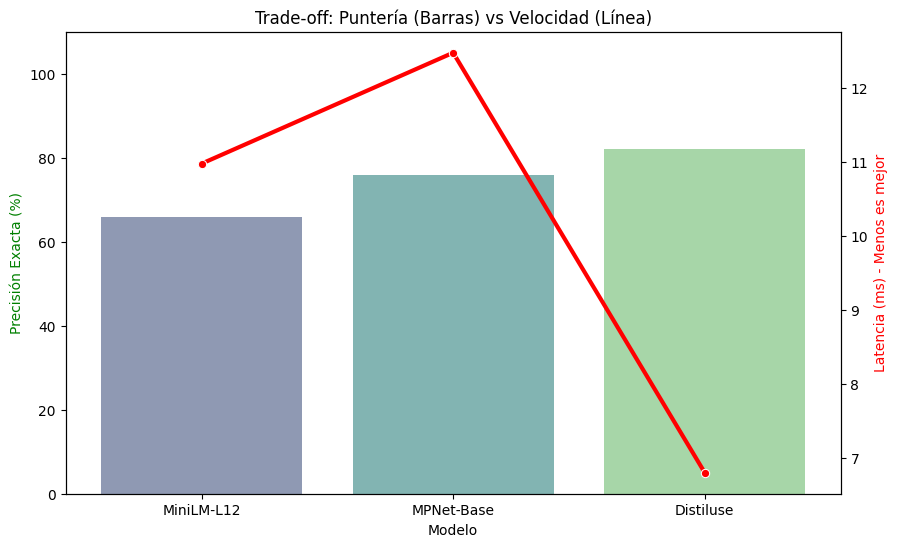


🏆 TABLA DE RESULTADOS:
       Modelo  Precisión Top-1 (%)  Precisión Top-5 (%)  \
0  MiniLM-L12                 66.0                 82.0   
1  MPNet-Base                 76.0                 90.0   
2   Distiluse                 82.0                 96.0   

   Latencia Consulta (ms)  
0               10.973339  
1               12.471795  
2                6.799908  


In [ ]:
# ==========================================
# 📐 BENCHMARK DE MODELOS DE EMBEDDING (RAG)
# ==========================================
!pip install sentence-transformers pandas tqdm deep-translator matplotlib seaborn

import pickle
import time
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util
from deep_translator import GoogleTranslator
from tqdm import tqdm
import random

# --- 1. CONFIGURACIÓN ---
# Archivo con los guiones (usamos el pkl porque ya lo tienes limpio,
# pero solo leeremos el texto, ignoraremos los vectores viejos)
PKL_PATH = "guiones_vectorizados_768.pkl"

# Modelos a Comparar
EMBEDDING_MODELS = {
    "MiniLM-L12": "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    "MPNet-Base": "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
    "Distiluse": "sentence-transformers/distiluse-base-multilingual-cased-v1"
}

# --- 2. PREPARACIÓN DE DATOS (GROUND TRUTH) ---
print("📂 Cargando datos de guiones...")
with open(PKL_PATH, 'rb') as f:
    data = pickle.load(f)

# Extraemos solo los textos. Limitamos a 2000 fragmentos para que el test sea rápido.
corpus_completo = [d['chunk_text'] for d in data if len(d['chunk_text']) > 50]
corpus_test = corpus_completo[:2000]

print(f"   ✅ Corpus cargado: {len(corpus_test)} fragmentos para búsqueda.")

# Generamos preguntas sintéticas (Español) -> Respuesta esperada (Inglés)
# Cogemos 50 fragmentos aleatorios y los traducimos para simular al usuario.
print("🤖 Generando preguntas de prueba (Traduciendo al español)...")
test_queries = []
translator = GoogleTranslator(source='en', target='es')

random.seed(42)
muestras = random.sample(list(enumerate(corpus_test)), 50) # (Indice, Texto)

for idx, text in tqdm(muestras):
    # Cogemos una frase significativa del chunk (los primeros 150 caracteres)
    snippet = text[:150]
    try:
        query_es = translator.translate(snippet)
        test_queries.append({
            "query": query_es,
            "correct_index": idx # Sabemos que este es el chunk correcto
        })
    except: pass

print(f"   ✅ Generadas {len(test_queries)} preguntas de prueba.")

# --- 3. EJECUCIÓN DEL BENCHMARK ---
results = []

for name, model_id in EMBEDDING_MODELS.items():
    print(f"\n🧪 Evaluando modelo: {name}...")

    # A. Carga del modelo
    t0 = time.time()
    model = SentenceTransformer(model_id, device='cuda')
    load_time = time.time() - t0

    # B. Indexación (Vectorizar los 2000 documentos)
    t0 = time.time()
    corpus_embeddings = model.encode(corpus_test, convert_to_tensor=True, show_progress_bar=False)
    indexing_time = time.time() - t0

    # C. Búsqueda (Retrieval)
    aciertos_top1 = 0
    aciertos_top5 = 0
    query_latency_acum = 0

    # --- CORRECCIÓN AQUÍ ---
    # Iteramos directamente sobre la lista de preguntas
    for q in test_queries:
        t_start = time.time()

        # 1. Vectorizar pregunta
        query_embedding = model.encode(q['query'], convert_to_tensor=True)

        # 2. Buscar (Semantic Search)
        hits = util.semantic_search(query_embedding, corpus_embeddings, top_k=5)[0]

        t_end = time.time()
        query_latency_acum += (t_end - t_start)

        # 3. Validar si encontró el correcto
        found_indices = [hit['corpus_id'] for hit in hits]

        if q['correct_index'] == found_indices[0]: # Está el primero
            aciertos_top1 += 1

        if q['correct_index'] in found_indices: # Está en el top 5
            aciertos_top5 += 1

    avg_latency = query_latency_acum / len(test_queries)
    accuracy_top1 = (aciertos_top1 / len(test_queries)) * 100
    accuracy_top5 = (aciertos_top5 / len(test_queries)) * 100

    results.append({
        "Modelo": name,
        "Latencia Consulta (ms)": avg_latency * 1000,
        "Tiempo Indexado (s)": indexing_time,
        "Precisión Top-1 (%)": accuracy_top1,
        "Precisión Top-5 (%)": accuracy_top5,
        "Dimensiones": corpus_embeddings.shape[1]
    })

# --- 4. VISUALIZACIÓN ---
df = pd.DataFrame(results)

# Gráfico 1: Precisión vs Latencia
fig, ax1 = plt.subplots(figsize=(10, 6))

# Barras para Precisión
sns.barplot(data=df, x="Modelo", y="Precisión Top-1 (%)", ax=ax1, palette="viridis", alpha=0.6)
ax1.set_ylabel("Precisión Exacta (%)", color='g')
ax1.set_ylim(0, 110)

# Línea para Latencia
ax2 = ax1.twinx()
sns.lineplot(data=df, x="Modelo", y="Latencia Consulta (ms)", ax=ax2, color='r', marker='o', linewidth=3)
ax2.set_ylabel("Latencia (ms) - Menos es mejor", color='r')

plt.title("Trade-off: Puntería (Barras) vs Velocidad (Línea)")
plt.show()

print("\n🏆 TABLA DE RESULTADOS:")
print(df[["Modelo", "Precisión Top-1 (%)", "Precisión Top-5 (%)", "Latencia Consulta (ms)"]])